# F1 Pit Stop Prediction — Training Framework

Binary classification: predict `PitNextLap` (whether the driver pits on the next lap).

Pipeline: load → EDA → preprocess → CV training → submission.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

import lightgbm as lgb

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
DATA_DIR = Path('.')

/home/propar/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load data

In [3]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

TARGET = 'PitNextLap'
ID_COL = 'id'

print('train:', train.shape, '| test:', test.shape)
train.head()

train: (439140, 16) | test: (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 2. Exploratory Data Analysis

The goal of this section is to **let you visually decide what the data really looks like** before any modeling decision.
Each subsection states *what* we plot and *why*; the code carries inline comments on technique choices.

Outline:
- 2.1 Dataset shape & data quality
- 2.2 Target distribution (class balance)
- 2.3 Numeric feature distributions (raw + clipped)
- 2.4 Numeric features split by target (boxplots)
- 2.5 Pit rate by Compound
- 2.6 Pit rate vs TyreLife (overall + per Compound)
- 2.7 Pit rate vs RaceProgress and LapNumber
- 2.8 Pit rate by Position
- 2.9 Pit rate by Stint number
- 2.10 Pit rate per Race
- 2.11 Pit rate by Year
- 2.12 Lap-time degradation curves (per Compound) — raw, detrended (2.12b), and `LapTime_Delta` view (2.12c)
- 2.13 Correlation heatmap
- 2.14 Driver effect
- 2.15 Train vs Test distribution overlay (covariate shift)

Data-integrity deep dive (added after running 2.1–2.15):
- 2.16 The 2023 anomaly — is the year salvageable or should it be dropped?
- 2.17 Sampling structure — train/test interleaving and lap coverage
- 2.18 PitNextLap anchoring — is the target tied to actual lap N+1?
- 2.19 Driver-ID composition — real codes vs synthetic D### vs other
- 2.20 Pre-Season Testing — is it polluting the training signal?

In [4]:
# 2.1 Dataset shape & data quality
# Confirm the data is as expected before drawing any inference:
#   - shape, dtypes, missing values, duplicate ids
#   - cardinality of categorical columns
#   - numeric summary stats (min/median/max etc.) — look out for absurd extremes

print(f'train: {train.shape} | test: {test.shape}')
print(f'duplicate ids in train: {train[ID_COL].duplicated().sum()} | test: {test[ID_COL].duplicated().sum()}')

print('\nDtypes:')
print(train.dtypes)

print('\nMissing values:')
miss = pd.concat([train.isna().sum().rename('train'), test.isna().sum().rename('test')], axis=1)
print(miss[(miss['train'] > 0) | (miss['test'] > 0)] if miss.values.sum() else '  (none)')

print('\nCategorical cardinality:')
for c in ['Driver', 'Compound', 'Race', 'Year']:
    print(f'  {c}: {train[c].nunique()} unique  | top = {train[c].value_counts().head(3).to_dict()}')

print('\nNumeric summary (train):')
train.describe().T

train: (439140, 16) | test: (188165, 15)
duplicate ids in train: 0 | test: 0

Dtypes:
id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object

Missing values:
Empty DataFrame
Columns: [train, test]
Index: []

Categorical cardinality:
  Driver: 887 unique  | top = {'MAS': 1682, 'RAI': 1669, 'BAR': 1656}
  Compound: 5 unique  | top = {'MEDIUM': 211141, 'HARD': 170518, 'SOFT': 38744}
  Race: 26 unique  | top = {'Dutch Grand Prix': 24462, 'Mexico City Grand Prix': 23672, 'Pre-Season Testing': 2249

,count,mean,std,min,25%,50%,75%,max
id,439140.0,219569.500000,126768.942943,0.000000,109784.75000,219569.500000,329354.250000,439139.000
Year,439140.0,2023.523544,1.024930,2022.000000,2023.00000,2024.000000,2024.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.00000,0.000000,0.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.00000,2.000000,2.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026


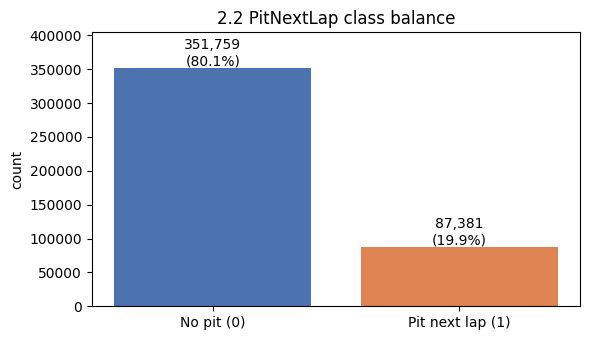

In [5]:
# 2.2 Target distribution (class balance)
# A binary classification problem is only meaningful in context of its class balance.
# Roughly 1 in 5 laps is followed by a pit on the next lap (≈19.9%).  This is
# moderately imbalanced — not severe enough to need resampling, but enough that AUC /
# Average Precision are better metrics than accuracy.

vc = train[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(['No pit (0)', 'Pit next lap (1)'], vc.values, color=['#4c72b0', '#dd8452'])
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}\n({v/vc.sum():.1%})',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('count'); ax.set_title('2.2 PitNextLap class balance')
ax.set_ylim(0, vc.max() * 1.15)
plt.tight_layout(); plt.show()

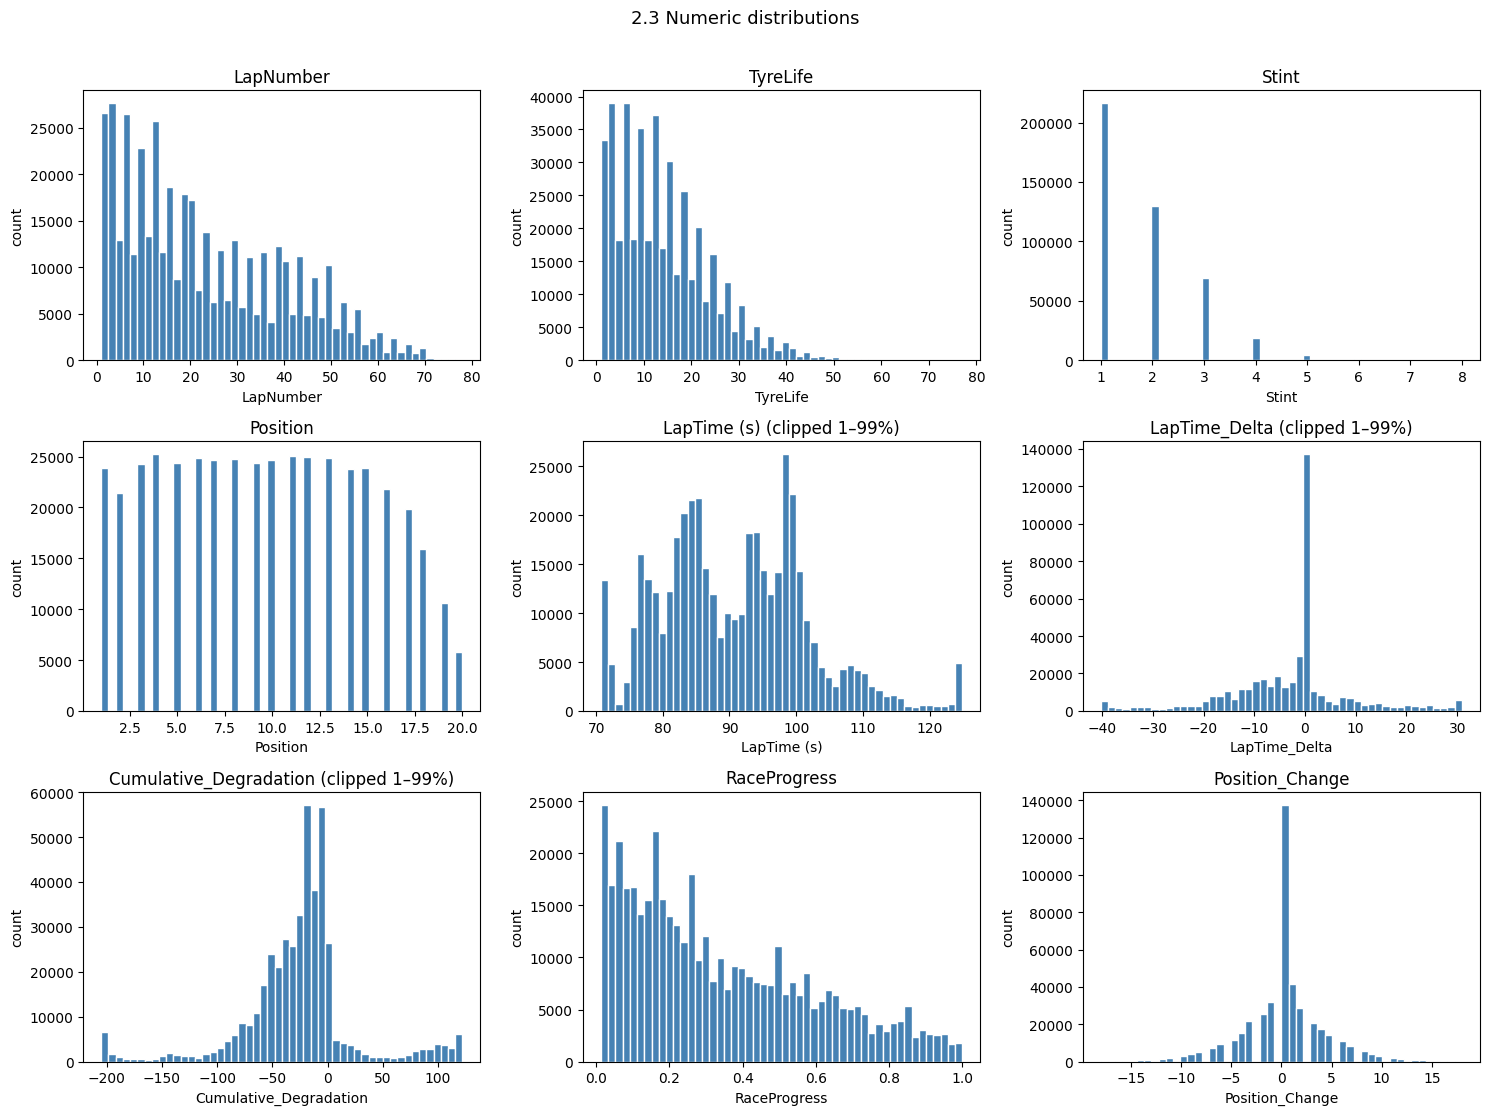

In [6]:
# 2.3 Numeric feature distributions (raw + clipped)
# We plot a histogram for every numeric feature so you can see the *shape* of each distribution
# (skew, multi-modality, outliers).  For features with extreme outliers (LapTime,
# LapTime_Delta, Cumulative_Degradation — see the describe() table above: max LapTime = 2507s
# which is a safety-car / red-flag lap), we ALSO show a clipped version trimmed to the
# 1st–99th percentile so the bulk of the distribution is actually visible.

# Helper: percentile clip a series to make plots readable when outliers dominate.
def clip_pct(s, lo=1, hi=99):
    a, b = np.nanpercentile(s, [lo, hi])
    return s.clip(a, b)

# Helper: bin a numeric column and compute mean target + count per bin.
# Used in 2.6 / 2.7 to draw smooth pit-rate curves.
def pit_rate_by(df, col, bins=None, target=TARGET):
    if bins is None:
        grp = df.groupby(col)[target]
    else:
        grp = df.groupby(pd.cut(df[col], bins=bins, include_lowest=True), observed=True)[target]
    out = grp.agg(['mean', 'count']).rename(columns={'mean': 'pit_rate', 'count': 'n'})
    return out.reset_index()

NUMERIC_COLS = ['LapNumber', 'TyreLife', 'Stint', 'Position',
                'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
                'RaceProgress', 'Position_Change']
HEAVY_TAIL = {'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation'}

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    s = clip_pct(train[col]) if col in HEAVY_TAIL else train[col]
    ax.hist(s, bins=50, color='steelblue', edgecolor='white')
    suffix = ' (clipped 1–99%)' if col in HEAVY_TAIL else ''
    ax.set_title(f'{col}{suffix}')
    ax.set_xlabel(col); ax.set_ylabel('count')
plt.suptitle('2.3 Numeric distributions', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

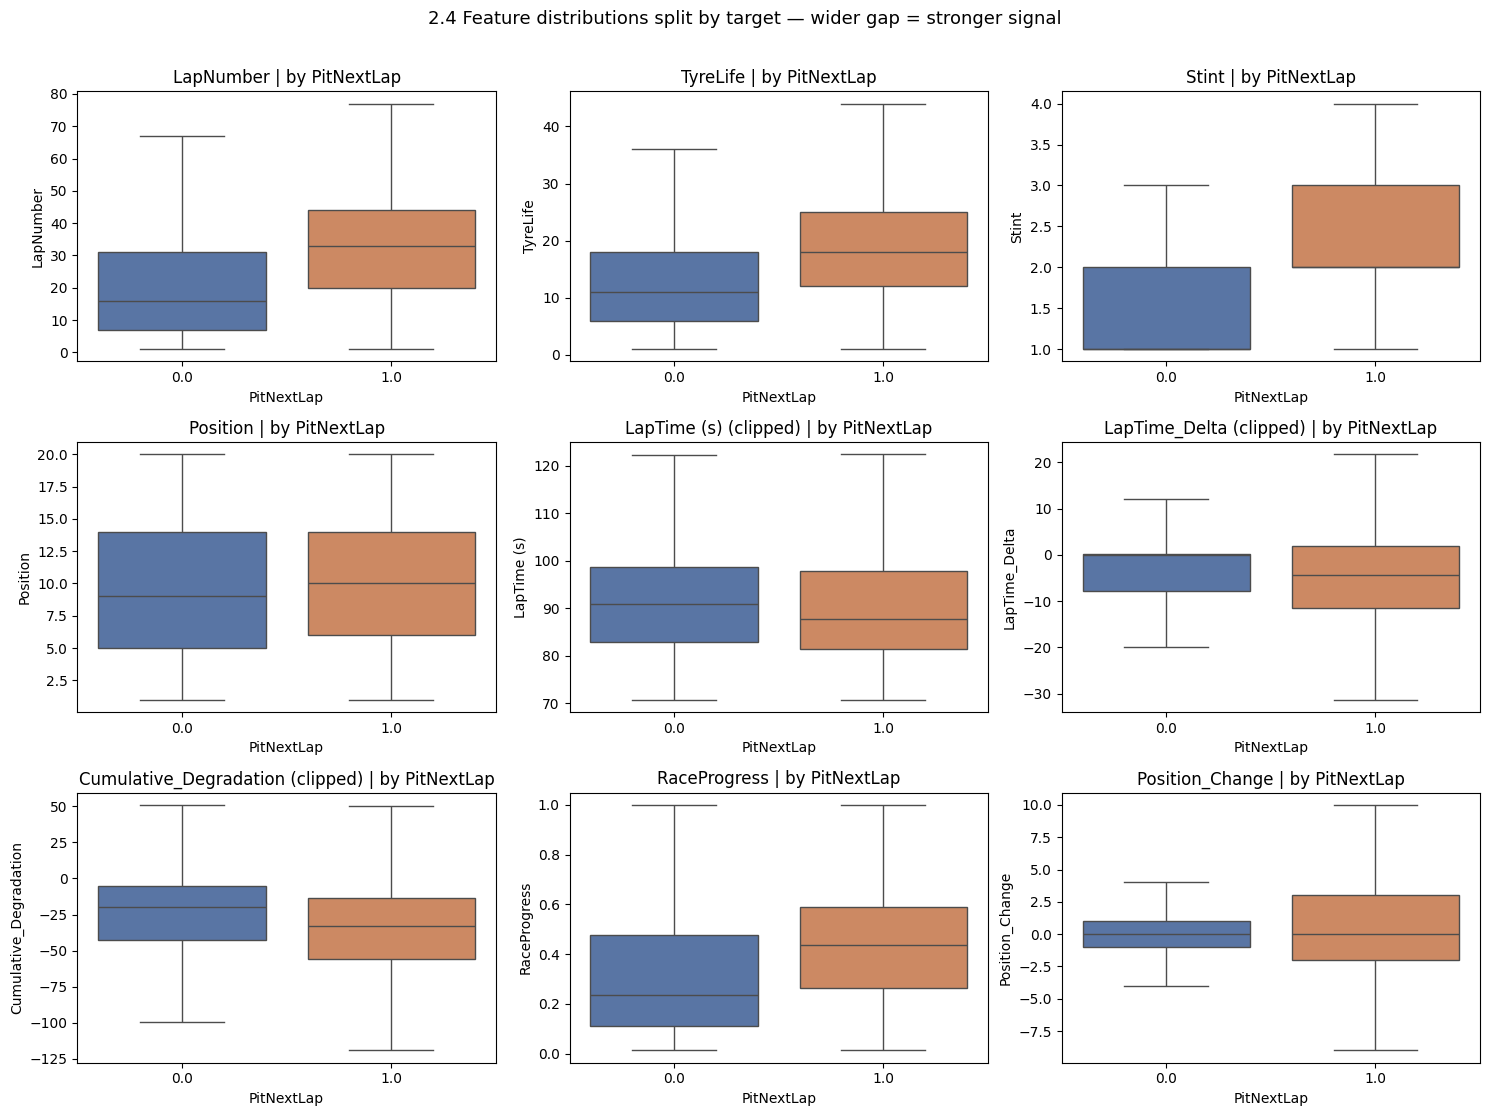

In [8]:
# 2.4 Numeric features split by target (boxplots)
# A boxplot per feature, hue=PitNextLap, lets you eyeball *how much* the distribution
# moves between pit-next-lap=0 and pit-next-lap=1.  Bigger separation → stronger signal.
# We use clipped versions for heavy-tail features so the boxes are readable.

split_df = train[NUMERIC_COLS + [TARGET]].copy()
for c in HEAVY_TAIL:
    split_df[c] = clip_pct(split_df[c])

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    # hue=TARGET is required so seaborn maps the palette dict to the two classes.
    sns.boxplot(data=split_df, x=TARGET, y=col, hue=TARGET, ax=ax,
                showfliers=False, palette={0.0: '#4c72b0', 1.0: '#dd8452'},
                legend=False)
    suffix = ' (clipped)' if col in HEAVY_TAIL else ''
    ax.set_title(f'{col}{suffix} | by PitNextLap')
plt.suptitle('2.4 Feature distributions split by target — wider gap = stronger signal',
             y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

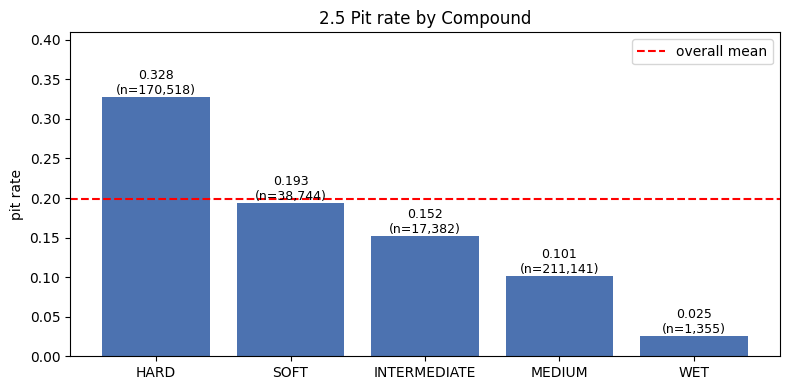

In [9]:
# 2.5 Pit rate by Compound
# Hypothesis from the rules of F1: softer compounds wear out faster, so they should
# show a higher pit rate per lap.  We plot the empirical pit rate per Compound
# alongside its sample size — small-n compounds (e.g. WET / INTERMEDIATE) will have
# wide error so don't over-interpret them.

rate_by_cmp = train.groupby('Compound')[TARGET].agg(['mean', 'count']).rename(
    columns={'mean': 'pit_rate', 'count': 'n'}).sort_values('pit_rate', ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(rate_by_cmp.index, rate_by_cmp['pit_rate'], color='#4c72b0')
ax.axhline(train[TARGET].mean(), color='red', linestyle='--', label='overall mean')
for b, (rate, n) in zip(bars, rate_by_cmp.values):
    ax.text(b.get_x() + b.get_width()/2, rate, f'{rate:.3f}\n(n={int(n):,})',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('pit rate'); ax.set_title('2.5 Pit rate by Compound')
ax.set_ylim(0, rate_by_cmp['pit_rate'].max() * 1.25); ax.legend()
plt.tight_layout(); plt.show()

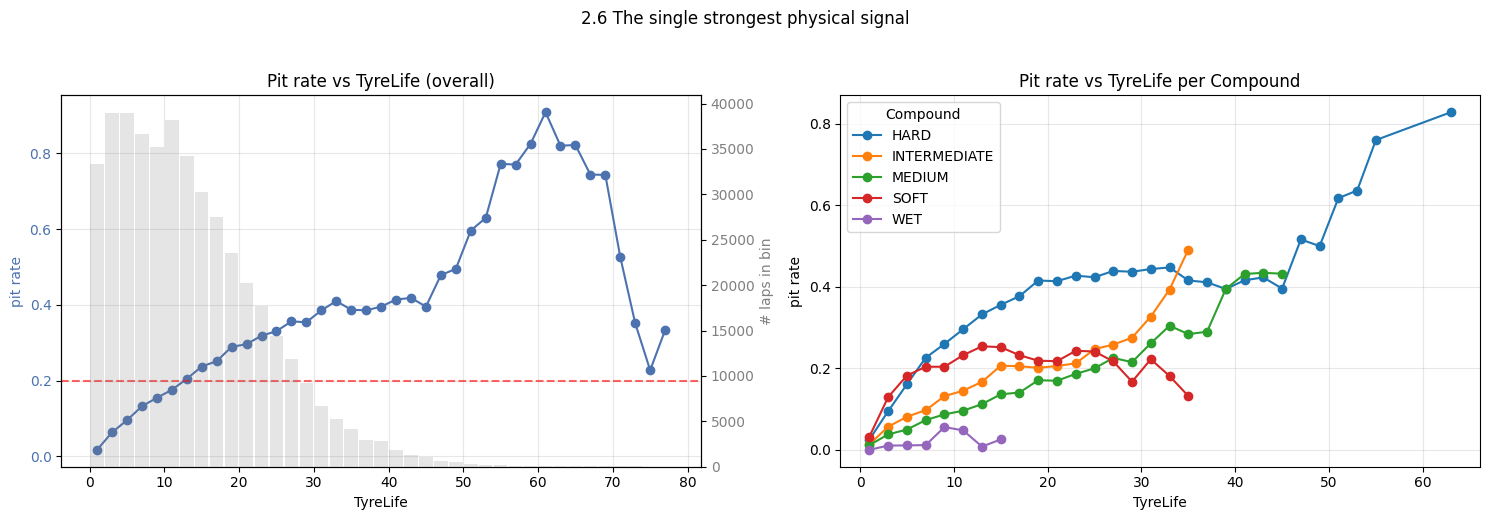

In [10]:
# 2.6 Pit rate vs TyreLife (overall and per Compound)
# TyreLife is the strongest physical predictor: as tyres wear, the probability of
# pitting next lap increases.  Two views:
#   (left)  overall pit-rate curve with a count overlay so we can see where data is sparse
#   (right) curves split by Compound — softs should pit at lower TyreLife than hards.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: pit rate vs TyreLife (binned), with count overlay on twin axis
tl_bins = np.arange(0, train['TyreLife'].max() + 3, 2)
tl = pit_rate_by(train, 'TyreLife', bins=tl_bins)
xs = [iv.mid for iv in tl['TyreLife']]
axes[0].plot(xs, tl['pit_rate'], marker='o', color='#4c72b0', label='pit rate')
axes[0].set_xlabel('TyreLife'); axes[0].set_ylabel('pit rate', color='#4c72b0')
axes[0].tick_params(axis='y', labelcolor='#4c72b0')
axes[0].axhline(train[TARGET].mean(), color='red', linestyle='--', alpha=0.6)
ax2 = axes[0].twinx()
ax2.bar(xs, tl['n'], width=1.8, alpha=0.2, color='gray', label='count')
ax2.set_ylabel('# laps in bin', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
axes[0].set_title('Pit rate vs TyreLife (overall)')
axes[0].grid(alpha=0.3)

# Right: pit rate vs TyreLife per Compound
for compound, sub in train.groupby('Compound'):
    tl_c = pit_rate_by(sub, 'TyreLife', bins=tl_bins)
    # Drop bins with too few samples to keep the curve stable
    tl_c = tl_c[tl_c['n'] >= 100]
    xs_c = [iv.mid for iv in tl_c['TyreLife']]
    axes[1].plot(xs_c, tl_c['pit_rate'], marker='o', label=compound)
axes[1].set_xlabel('TyreLife'); axes[1].set_ylabel('pit rate')
axes[1].set_title('Pit rate vs TyreLife per Compound')
axes[1].legend(title='Compound'); axes[1].grid(alpha=0.3)

plt.suptitle('2.6 The single strongest physical signal', y=1.03)
plt.tight_layout(); plt.show()

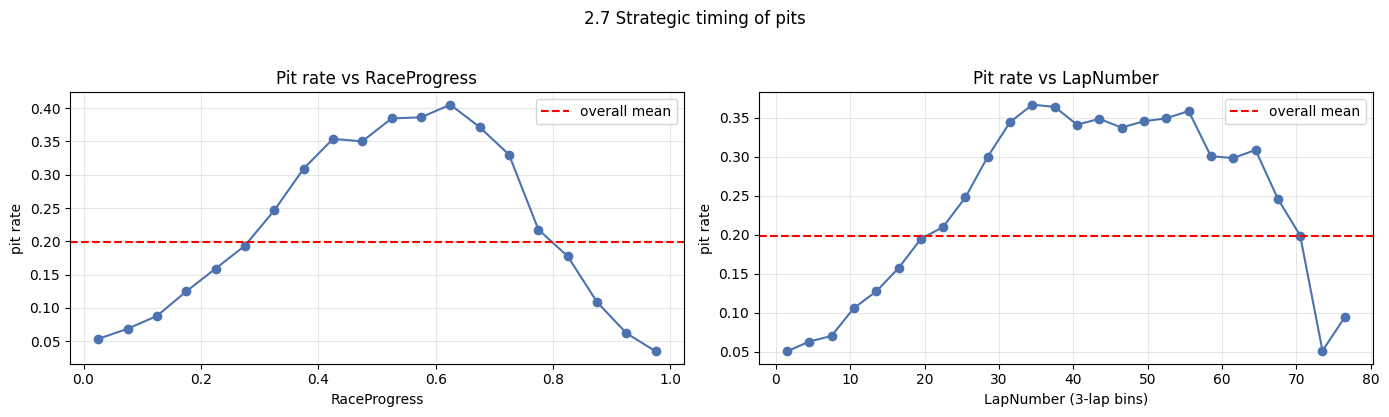

In [11]:
# 2.7 Pit rate vs RaceProgress and LapNumber
# RaceProgress (0..1) is the lap normalised by race length.  This is more comparable
# across tracks than raw LapNumber (which depends on race length).  We bin both and
# plot mean pit rate per bin — expect peaks at typical strategy windows (~0.3–0.4 for
# first stop, ~0.6–0.7 for second stop, ~0 right after start, near 0 at the very end).

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RaceProgress curve
rp = pit_rate_by(train, 'RaceProgress', bins=np.linspace(0, 1, 21))
xs_rp = [iv.mid for iv in rp['RaceProgress']]
axes[0].plot(xs_rp, rp['pit_rate'], marker='o', color='#4c72b0')
axes[0].axhline(train[TARGET].mean(), color='red', linestyle='--', label='overall mean')
axes[0].set_xlabel('RaceProgress'); axes[0].set_ylabel('pit rate')
axes[0].set_title('Pit rate vs RaceProgress'); axes[0].legend(); axes[0].grid(alpha=0.3)

# LapNumber curve (binned)
ln = pit_rate_by(train, 'LapNumber', bins=np.arange(0, train['LapNumber'].max() + 4, 3))
xs_ln = [iv.mid for iv in ln['LapNumber']]
axes[1].plot(xs_ln, ln['pit_rate'], marker='o', color='#4c72b0')
axes[1].axhline(train[TARGET].mean(), color='red', linestyle='--', label='overall mean')
axes[1].set_xlabel('LapNumber (3-lap bins)'); axes[1].set_ylabel('pit rate')
axes[1].set_title('Pit rate vs LapNumber'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('2.7 Strategic timing of pits', y=1.03)
plt.tight_layout(); plt.show()

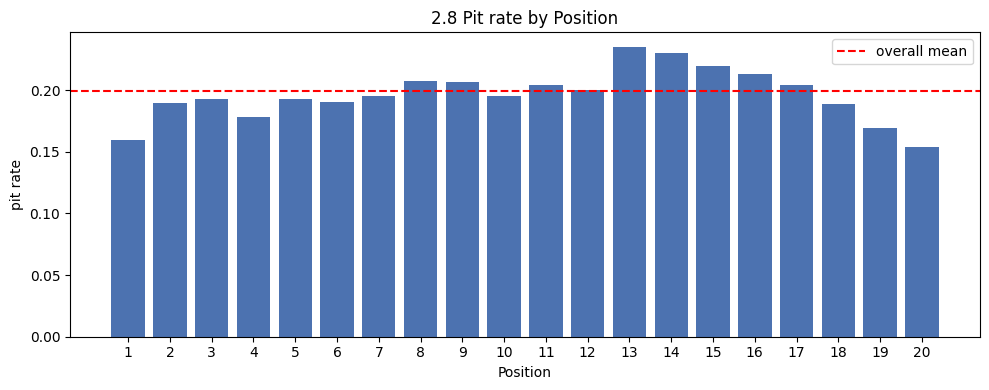

In [12]:
# 2.8 Pit rate by Position
# Strategic intuition: front-runners have track position to defend (undercut/overcut
# behavior), backmarkers have less to lose by pitting.  We plot pit rate at each track
# position 1..20 to see if the relationship is monotonic, U-shaped, or flat.

rate_pos = train.groupby('Position')[TARGET].agg(['mean', 'count']).rename(
    columns={'mean': 'pit_rate', 'count': 'n'})
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(rate_pos.index, rate_pos['pit_rate'], color='#4c72b0')
ax.axhline(train[TARGET].mean(), color='red', linestyle='--', label='overall mean')
ax.set_xticks(rate_pos.index)
ax.set_xlabel('Position'); ax.set_ylabel('pit rate')
ax.set_title('2.8 Pit rate by Position'); ax.legend()
plt.tight_layout(); plt.show()

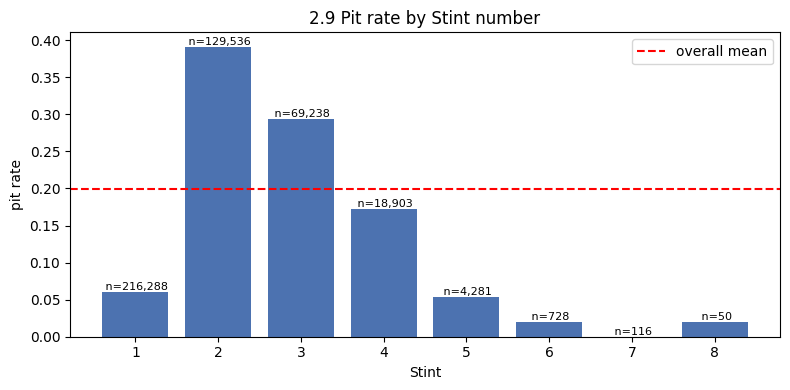

In [13]:
# 2.9 Pit rate by Stint number
# Stint = which tyre set the driver is on (1 = starting tyres).  Pit rate per stint
# tells us where in the strategy pit decisions concentrate (e.g. 1→2 vs 2→3 transition).
# Later stints tend to be near the end of the race so behavior may differ.

rate_stint = train.groupby('Stint')[TARGET].agg(['mean', 'count']).rename(
    columns={'mean': 'pit_rate', 'count': 'n'})
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rate_stint.index, rate_stint['pit_rate'], color='#4c72b0')
ax.axhline(train[TARGET].mean(), color='red', linestyle='--', label='overall mean')
for x, (r, n) in zip(rate_stint.index, rate_stint.values):
    ax.text(x, r, f' n={int(n):,}', ha='center', va='bottom', fontsize=8, rotation=0)
ax.set_xlabel('Stint'); ax.set_ylabel('pit rate')
ax.set_title('2.9 Pit rate by Stint number'); ax.legend()
plt.tight_layout(); plt.show()

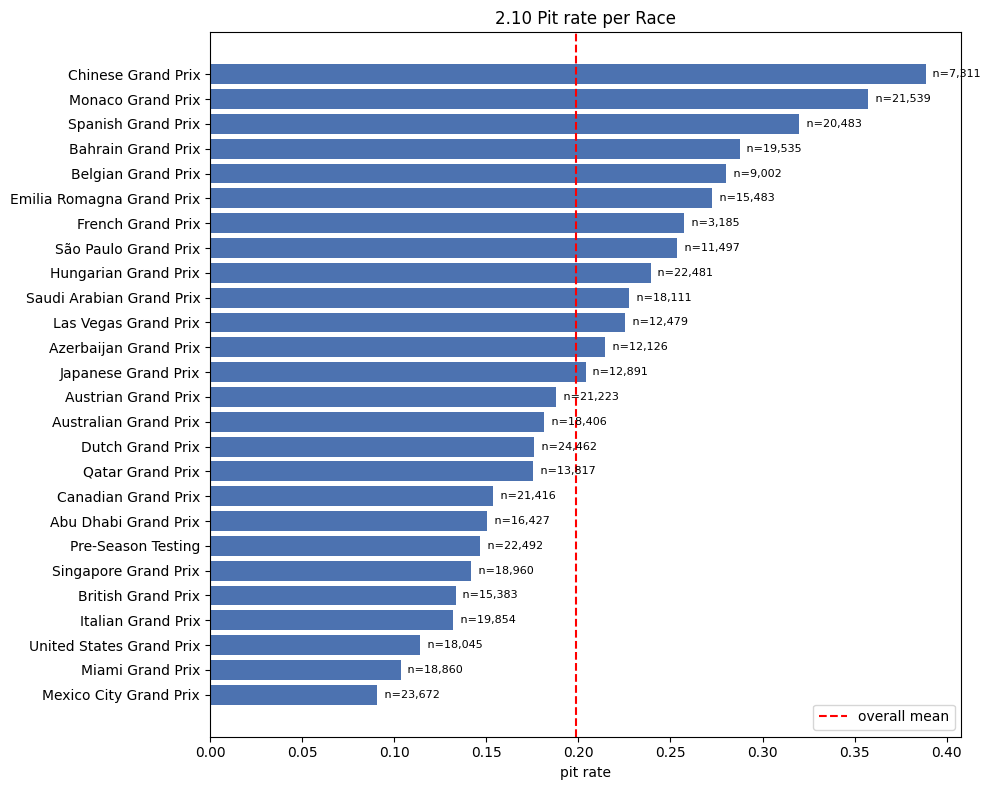

In [14]:
# 2.10 Pit rate per Race (track effect)
# Tracks differ massively in tyre wear and safety-car probability.  Monaco has very
# different optimal strategy than Spa.  We expect the per-race pit rate to span a wide
# range — confirming Race must be a feature.  We sort by pit rate and annotate sample
# size on the right so you can spot rates that are unstable due to small n.

rate_race = train.groupby('Race')[TARGET].agg(['mean', 'count']).rename(
    columns={'mean': 'pit_rate', 'count': 'n'}).sort_values('pit_rate')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(rate_race.index, rate_race['pit_rate'], color='#4c72b0')
ax.axvline(train[TARGET].mean(), color='red', linestyle='--', label='overall mean')
for i, (r, n) in enumerate(rate_race.values):
    ax.text(r + 0.002, i, f' n={int(n):,}', va='center', fontsize=8)
ax.set_xlabel('pit rate'); ax.set_title('2.10 Pit rate per Race')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

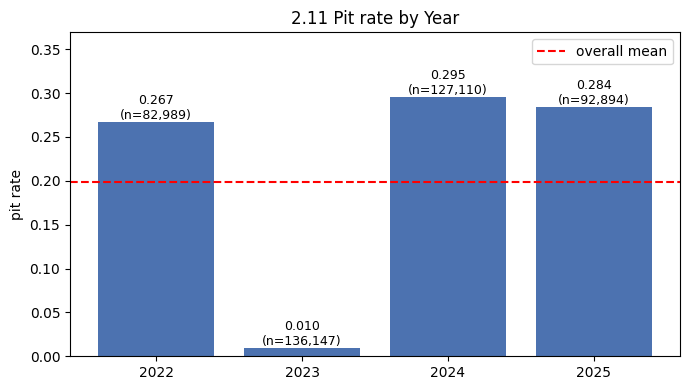

In [15]:
# 2.11 Pit rate by Year
# Sanity check for temporal stability or regime change.  If 2025 (the most recent year
# in train and the basis of test) has a markedly different pit rate, our CV estimate
# may be biased relative to the true test distribution.

rate_year = train.groupby('Year')[TARGET].agg(['mean', 'count']).rename(
    columns={'mean': 'pit_rate', 'count': 'n'})
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rate_year.index.astype(str), rate_year['pit_rate'], color='#4c72b0')
ax.axhline(train[TARGET].mean(), color='red', linestyle='--', label='overall mean')
for x, (r, n) in enumerate(rate_year.values):
    ax.text(x, r, f'{r:.3f}\n(n={int(n):,})', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('pit rate'); ax.set_title('2.11 Pit rate by Year'); ax.legend()
ax.set_ylim(0, rate_year['pit_rate'].max() * 1.25)
plt.tight_layout(); plt.show()

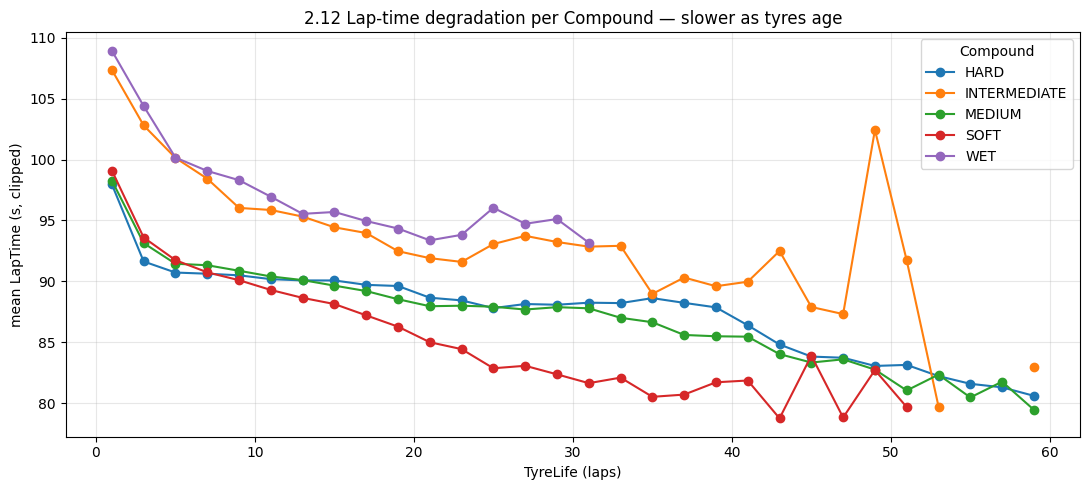

In [21]:
# 2.12 Lap-time degradation curves (per Compound)
# This visualises the *physical reason* why pit stops happen: tyres lose grip with use.
# We bin TyreLife and plot the mean LapTime (clipped to drop safety-car laps) for each
# Compound.  Expect SOFT to start fastest but degrade steeply, HARD to be slower but
# flatter, MEDIUM in between.  If the curves don't look that way, the Compound labels
# may be noisy.

deg = train[['TyreLife', 'Compound', 'LapTime (s)']].copy()
deg['LapTime_clipped'] = clip_pct(deg['LapTime (s)'])
deg['TL_bin'] = pd.cut(deg['TyreLife'], bins=np.arange(0, 61, 2))
agg = deg.groupby(['TL_bin', 'Compound'], observed=True)['LapTime_clipped'].mean().unstack()
# Convert bin midpoints for x-axis
agg.index = [iv.mid for iv in agg.index]

fig, ax = plt.subplots(figsize=(11, 5))
for compound in agg.columns:
    ax.plot(agg.index, agg[compound], marker='o', label=compound)
ax.set_xlabel('TyreLife (laps)'); ax.set_ylabel('mean LapTime (s, clipped)')
ax.set_title('2.12 Lap-time degradation per Compound — slower as tyres age')
ax.legend(title='Compound'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

/tmp/ipykernel_68324/2687936711.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deg2['TL_bin'] = pd.cut(deg2['TyreLife'], bins=np.arange(0, 41, 2))


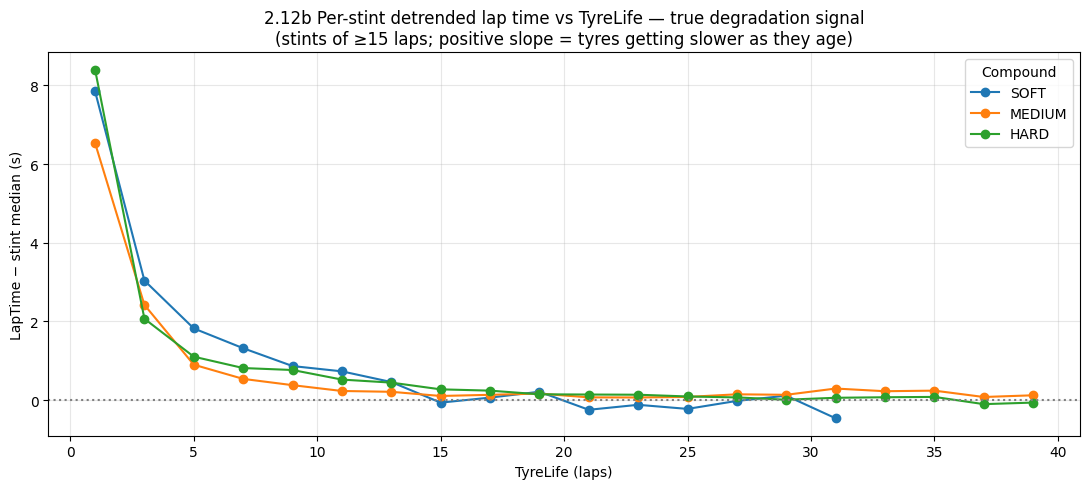

In [17]:
# 2.12b True tyre-degradation signal (controls for fuel burn + survivorship)
# Section 2.12 shows lap times going DOWN with TyreLife — opposite to physics.  Three
# confounders cause this:
#   (1) Fuel burn: ~100 kg burned over a race -> ~3 s/lap faster end-of-race.  TyreLife
#       correlates with race progress, so old tyres = light car = fast laps.
#   (2) Tyre warm-up: laps 1-3 of a stint are out-laps where tyres aren't at temperature.
#   (3) Survivorship bias: drivers pit when tyres degrade, so high-TyreLife observations
#       are a selected sample of well-behaving tyres.
#
# Fix: within each stint, subtract that stint's own median lap time.  Fuel burn within
# one stint is small (~0.5 s) compared to across the race, and per-stint baselining
# removes driver/track/fuel offsets.  We also restrict to stints of >=15 laps so we are
# comparing tyres that genuinely went the distance — survivorship still applies but the
# trend should now slope UP if real degradation exists.

stint_key = ['Driver', 'Race', 'Year', 'Stint']
deg2 = train[stint_key + ['TyreLife', 'Compound', 'LapTime (s)']].copy()
deg2['LapTime_clipped'] = clip_pct(deg2['LapTime (s)'])
g = deg2.groupby(stint_key)
deg2['stint_median'] = g['LapTime_clipped'].transform('median')
deg2['stint_len']    = g['TyreLife'].transform('max')
deg2['residual']     = deg2['LapTime_clipped'] - deg2['stint_median']
deg2 = deg2[deg2['stint_len'] >= 15]

deg2['TL_bin'] = pd.cut(deg2['TyreLife'], bins=np.arange(0, 41, 2))
agg2 = deg2.groupby(['TL_bin', 'Compound'], observed=True)['residual'].agg(['mean', 'count']).unstack()
mids = [iv.mid for iv in agg2.index]

fig, ax = plt.subplots(figsize=(11, 5))
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    if ('mean', compound) in agg2.columns:
        # Drop bins with too few samples
        s = agg2[('mean', compound)]
        n = agg2[('count', compound)]
        mask = n >= 200
        ax.plot([m for m, ok in zip(mids, mask) if ok],
                s[mask].values, marker='o', label=compound)
ax.axhline(0, color='grey', linestyle=':')
ax.set_xlabel('TyreLife (laps)')
ax.set_ylabel('LapTime − stint median (s)')
ax.set_title('2.12b Per-stint detrended lap time vs TyreLife — true degradation signal\n'
             '(stints of ≥15 laps; positive slope = tyres getting slower as they age)')
ax.legend(title='Compound'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

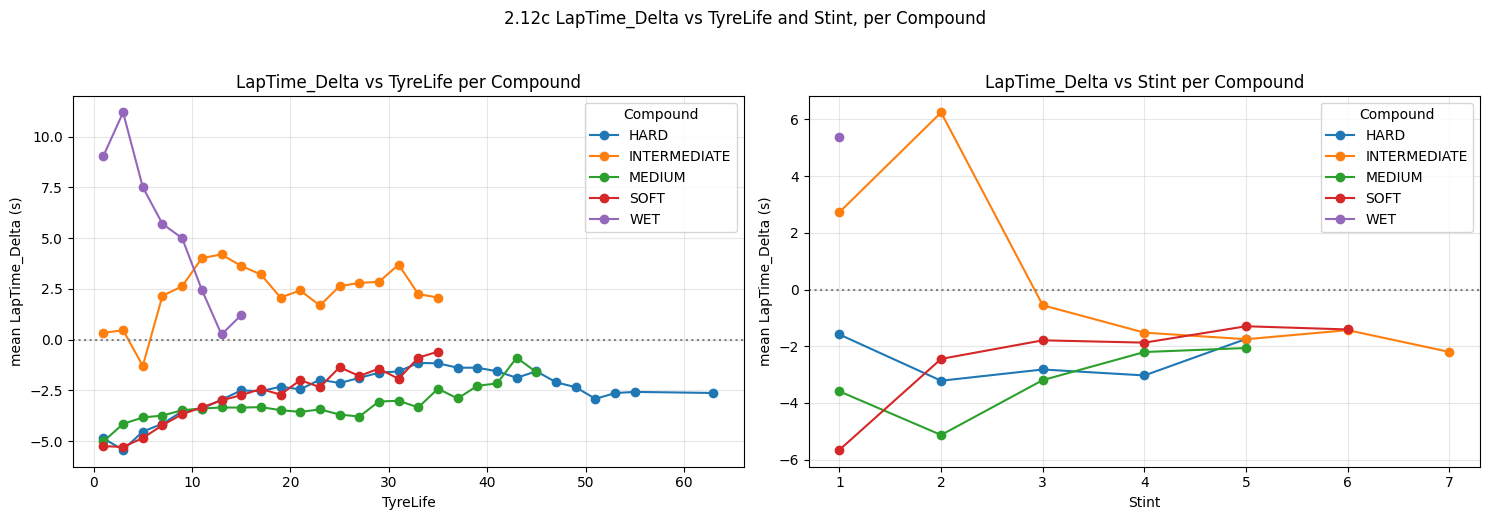

In [23]:
# 2.12c LapTime_Delta vs TyreLife and Stint, per Compound
# LapTime_Delta is the lap-over-lap change in pace.  Splitting by Compound lets us
# compare wear behaviour: softs should show a steeper rise in delta at high TyreLife
# than hards.  Heavy outliers are clipped to 1–99% so the curves stay readable, and
# bins with <100 samples are dropped so a couple of noisy points don't dominate.

dlt = train[['TyreLife', 'Stint', 'Compound', 'LapTime_Delta']].copy()
dlt['LapTime_Delta'] = clip_pct(dlt['LapTime_Delta'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: mean delta vs TyreLife, one line per Compound
tl_bins = np.arange(0, train['TyreLife'].max() + 3, 2)
dlt['TL_bin'] = pd.cut(dlt['TyreLife'], bins=tl_bins, include_lowest=True)
agg_tl = dlt.groupby(['TL_bin', 'Compound'], observed=True)['LapTime_Delta'].agg(['mean', 'count']).reset_index()
agg_tl['TL_mid'] = agg_tl['TL_bin'].apply(lambda iv: iv.mid)
for compound, sub in agg_tl.groupby('Compound'):
    sub = sub[sub['count'] >= 100]
    if not sub.empty:
        axes[0].plot(sub['TL_mid'], sub['mean'], marker='o', label=compound)
axes[0].axhline(0, color='grey', linestyle=':')
axes[0].set_xlabel('TyreLife'); axes[0].set_ylabel('mean LapTime_Delta (s)')
axes[0].set_title('LapTime_Delta vs TyreLife per Compound')
axes[0].legend(title='Compound'); axes[0].grid(alpha=0.3)

# Right: mean delta vs Stint, one line per Compound
agg_st = dlt.groupby(['Stint', 'Compound'], observed=True)['LapTime_Delta'].agg(['mean', 'count']).reset_index()
for compound, sub in agg_st.groupby('Compound'):
    sub = sub[sub['count'] >= 100]
    if not sub.empty:
        axes[1].plot(sub['Stint'], sub['mean'], marker='o', label=compound)
axes[1].axhline(0, color='grey', linestyle=':')
axes[1].set_xlabel('Stint'); axes[1].set_ylabel('mean LapTime_Delta (s)')
axes[1].set_title('LapTime_Delta vs Stint per Compound')
axes[1].legend(title='Compound'); axes[1].grid(alpha=0.3)

plt.suptitle('2.12c LapTime_Delta vs TyreLife and Stint, per Compound', y=1.03)
plt.tight_layout(); plt.show()

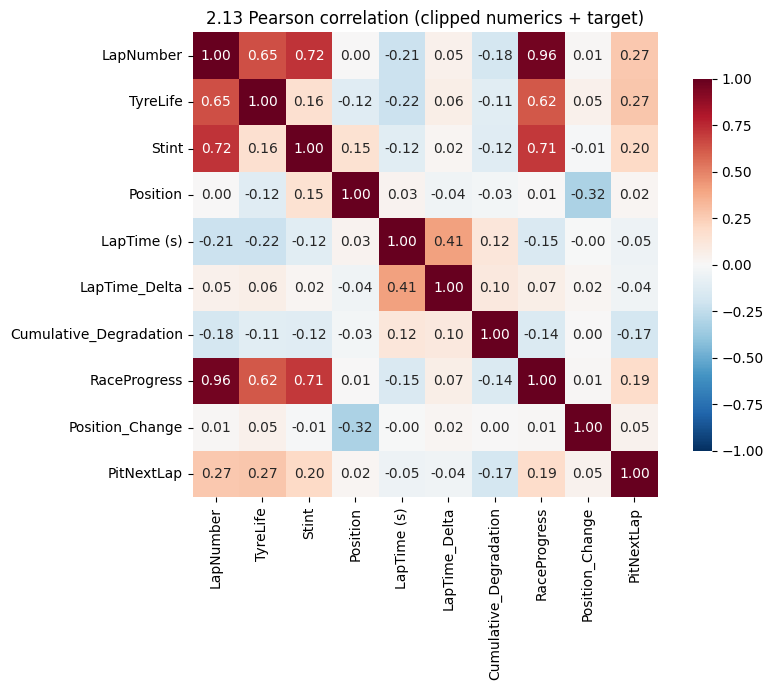

In [18]:
# 2.13 Correlation heatmap (numeric features incl. target)
# A first-pass linear-association check.  Trees handle non-linear signal too, so a low
# correlation here does NOT mean a feature is useless — but it tells you which pairs
# are highly redundant (collinear) and which features have no monotone link with the target.
# Heavy-tail features are clipped first so a handful of outliers don't dominate the correlation.

corr_df = train[NUMERIC_COLS + [TARGET]].copy()
for c in HEAVY_TAIL:
    corr_df[c] = clip_pct(corr_df[c])
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('2.13 Pearson correlation (clipped numerics + target)')
plt.tight_layout(); plt.show()

Drivers with >=100 laps: 485
Per-driver pit rate — min=0.014, max=0.565, std=0.064
Cramér's V (Driver vs PitNextLap) = 0.1352  (0=no link, 1=perfect)


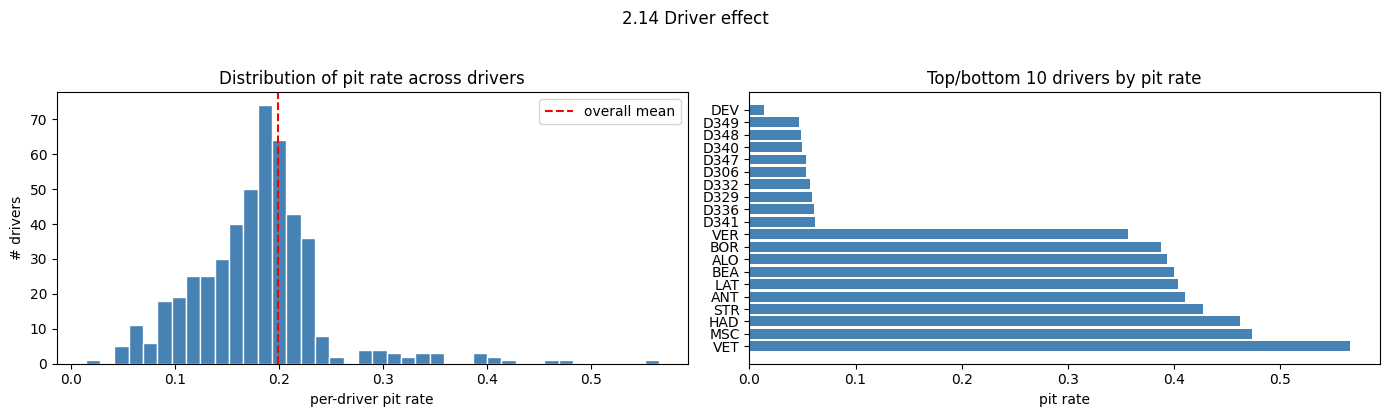

In [19]:
# 2.14 Driver effect
# 887 distinct driver IDs is a LOT relative to ~440k laps.  We want to know:
#   (a) is per-driver pit rate variable enough to be useful as a feature?
#   (b) is the effect statistically meaningful (Cramér's V)?
# Consider only drivers with at least 100 laps so per-driver rates are stable.

driver_stats = train.groupby('Driver')[TARGET].agg(['mean', 'count']).rename(
    columns={'mean': 'pit_rate', 'count': 'laps'})
driver_stats = driver_stats[driver_stats['laps'] >= 100].sort_values('pit_rate', ascending=False)

# Cramér's V — strength of association between Driver (categorical) and PitNextLap (binary)
from scipy.stats import chi2_contingency
ct = pd.crosstab(train['Driver'], train[TARGET])
chi2, p, dof, _ = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"Drivers with >=100 laps: {len(driver_stats)}")
print(f"Per-driver pit rate — min={driver_stats['pit_rate'].min():.3f}, "
      f"max={driver_stats['pit_rate'].max():.3f}, std={driver_stats['pit_rate'].std():.3f}")
print(f"Cramér's V (Driver vs PitNextLap) = {cramers_v:.4f}  (0=no link, 1=perfect)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(driver_stats['pit_rate'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(train[TARGET].mean(), color='red', linestyle='--', label='overall mean')
axes[0].set_xlabel('per-driver pit rate'); axes[0].set_ylabel('# drivers')
axes[0].set_title('Distribution of pit rate across drivers'); axes[0].legend()
top_bot = pd.concat([driver_stats.head(10), driver_stats.tail(10)])
axes[1].barh(top_bot.index, top_bot['pit_rate'], color='steelblue')
axes[1].set_title('Top/bottom 10 drivers by pit rate'); axes[1].set_xlabel('pit rate')
plt.suptitle('2.14 Driver effect', y=1.03)
plt.tight_layout(); plt.show()

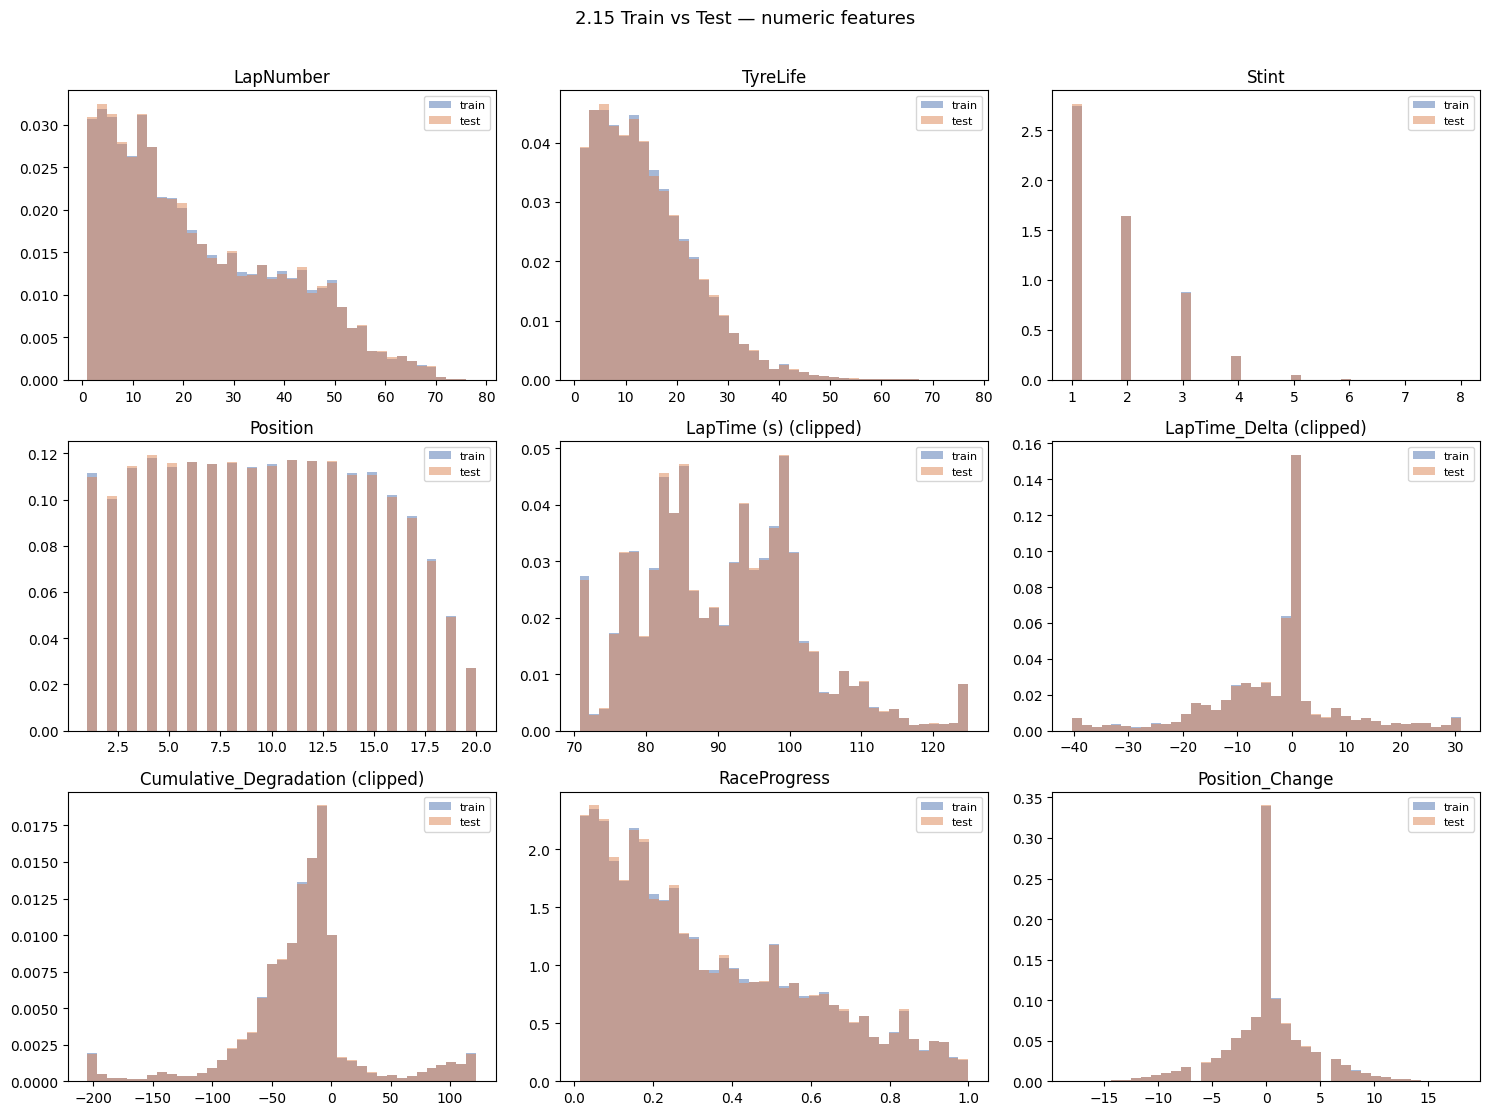

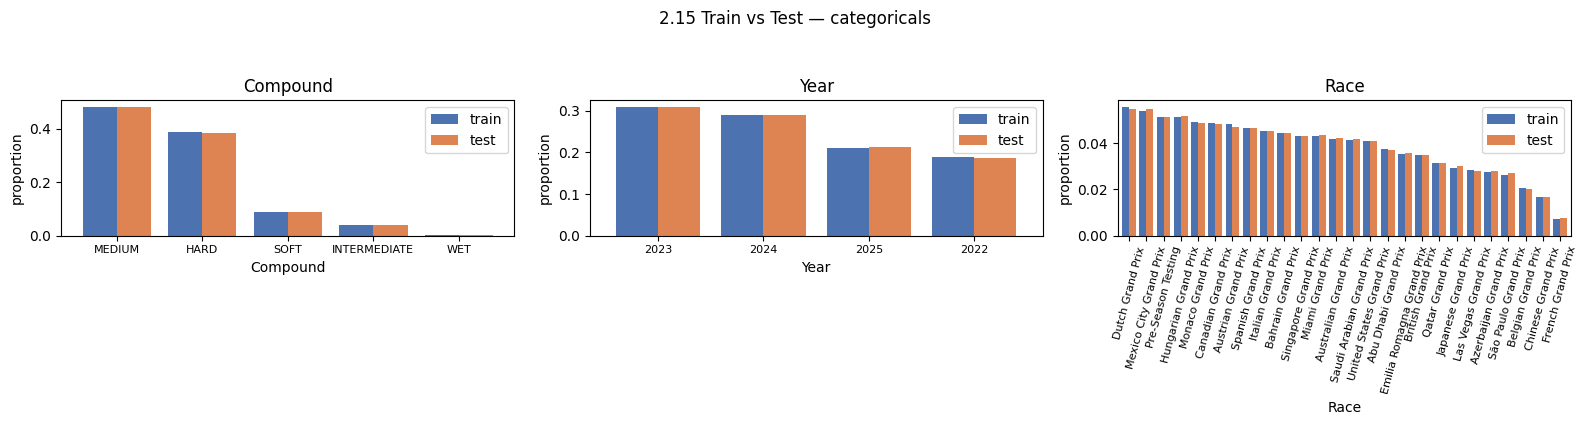

In [20]:
# 2.15 Train vs Test distribution overlay (covariate shift check)
# CV scores are only trustworthy if train and test come from the same distribution.
# We overlay the marginal distribution of every numeric feature for train vs test, and
# the proportion of each category for the categorical features.  Any large gap is a
# warning that holdout performance may differ from leaderboard performance.

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    a = clip_pct(train[col]) if col in HEAVY_TAIL else train[col]
    b = clip_pct(test[col])  if col in HEAVY_TAIL else test[col]
    bins = np.linspace(min(a.min(), b.min()), max(a.max(), b.max()), 40)
    ax.hist(a, bins=bins, density=True, alpha=0.5, label='train', color='#4c72b0')
    ax.hist(b, bins=bins, density=True, alpha=0.5, label='test',  color='#dd8452')
    suffix = ' (clipped)' if col in HEAVY_TAIL else ''
    ax.set_title(f'{col}{suffix}'); ax.legend(fontsize=8)
plt.suptitle('2.15 Train vs Test — numeric features', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

# Categorical comparison (proportions side-by-side)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Compound', 'Year', 'Race']):
    a = train[col].value_counts(normalize=True)
    b = test[col].value_counts(normalize=True)
    df_cmp = pd.DataFrame({'train': a, 'test': b}).fillna(0).sort_values('train', ascending=False)
    df_cmp.plot.bar(ax=ax, width=0.8, color=['#4c72b0', '#dd8452'])
    ax.set_title(f'{col}'); ax.set_ylabel('proportion')
    ax.tick_params(axis='x', labelrotation=75 if col == 'Race' else 0, labelsize=8)
plt.suptitle('2.15 Train vs Test — categoricals', y=1.05)
plt.tight_layout(); plt.show()

In [ ]:
# 2.16 The 2023 anomaly — diagnostic
# 2.11 surfaced a 30x drop in pit rate for 2023 (0.96% vs 26-30% other years).  We
# need to know whether it's salvageable (e.g. labels off but features fine) or so
# corrupted that 2023 should be dropped from training.
#
# Three views:
#   (a) Per-Race x Year heatmap of PitStop sum and lap count — is the drop uniform
#       across all 26 races in 2023, or concentrated in a few?
#   (b) Per-Year distribution of TyreLife / Stint / max LapNumber — features-only
#       sanity check.  If features look normal, the issue is target-only.
#   (c) Pit rate vs TyreLife curve, 2023 vs not-2023 — if 2023 is shifted/scaled
#       similarly, target-rebuilding via PitStop.shift() may work.
#   (d) Random sample of 2023 rows for eyeballing.

# (a) Per-(Race, Year) PitStop totals
pivot_pit = train.pivot_table(index='Race', columns='Year', values='PitStop',
                              aggfunc='sum', fill_value=0).astype(int)
pivot_n   = train.pivot_table(index='Race', columns='Year', values='PitStop',
                              aggfunc='size', fill_value=0).astype(int)
print('PitStop sum per (Race, Year):')
print(pivot_pit.to_string())
print('\nLap count per (Race, Year):')
print(pivot_n.to_string())
print('\nImplied pit-stop-per-lap rate per (Race, Year):')
rate_pivot = (pivot_pit / pivot_n.replace(0, np.nan))
print(rate_pivot.round(3).to_string())

# (b) Feature distributions per year — are features sensible in 2023?
print('\nNumeric feature stats per Year:')
print(train.groupby('Year')[['LapNumber','TyreLife','Stint','LapTime (s)','Position']].describe()
      .round(2).T.to_string())

# (c) Pit-rate-vs-TyreLife curve, 2023 vs others
fig, ax = plt.subplots(figsize=(10, 5))
tl_bins = np.arange(0, 51, 2)
for label, sub in [('2023', train[train['Year']==2023]),
                   ('not 2023', train[train['Year']!=2023])]:
    curve = pit_rate_by(sub, 'TyreLife', bins=tl_bins)
    curve = curve[curve['n'] >= 100]
    xs = [iv.mid for iv in curve['TyreLife']]
    ax.plot(xs, curve['pit_rate'], marker='o', label=f'{label} (n_rows={len(sub):,})')
ax.set_xlabel('TyreLife'); ax.set_ylabel('pit rate')
ax.set_title('2.16 Pit rate vs TyreLife — 2023 vs other years')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# (d) Eyeball random 2023 rows
print('\nRandom 20 rows from 2023:')
print(train[train['Year']==2023].sample(20, random_state=0)[
    ['Driver','Race','LapNumber','TyreLife','Stint','Compound','PitStop','PitNextLap']
].to_string())

In [ ]:
# 2.17 Sampling structure — visualise the train/test interleaving
# Train and test share laps inside the SAME (Driver, Race, Year) groups.  We confirm
# how the data was sub-sampled by:
#   (1) showing which laps appear in train/test/missing for a few example stints,
#   (2) plotting the distribution of "fraction of physical laps captured" per group,
#   (3) plotting the distribution of consecutive-lap gaps within train rows.

combined = pd.concat([
    train[['Driver','Race','Year','LapNumber']].assign(_split='train'),
    test[['Driver','Race','Year','LapNumber']].assign(_split='test')
], ignore_index=True)

# (1) Strip plot for 6 example (Driver, Race, Year) groups with high coverage.
group_cnt = combined.groupby(['Driver','Race','Year']).size().sort_values(ascending=False)
examples = group_cnt.head(60).sample(6, random_state=0).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 5), sharey=True)
for ax, (drv, race, yr) in zip(axes.flat, examples):
    sub = combined[(combined['Driver']==drv) & (combined['Race']==race) & (combined['Year']==yr)]
    max_lap = int(sub['LapNumber'].max())
    laps_train = set(sub.loc[sub['_split']=='train', 'LapNumber'].astype(int))
    laps_test  = set(sub.loc[sub['_split']=='test',  'LapNumber'].astype(int))
    for lap in range(1, max_lap + 1):
        if   lap in laps_train: c = '#4c72b0'
        elif lap in laps_test:  c = '#dd8452'
        else:                   c = '#dddddd'
        ax.bar(lap, 1, color=c, width=1.0)
    ax.set_xlim(0.5, max_lap + 0.5); ax.set_ylim(0, 1.2); ax.set_yticks([])
    ax.set_title(f'{drv} | {race[:18]} | {yr}\nmax_lap={max_lap}', fontsize=9)
    ax.set_xlabel('LapNumber')
plt.suptitle('2.17 Lap presence per stint — blue=train, orange=test, grey=missing', y=1.05)
plt.tight_layout(); plt.show()

# (2) Coverage histogram
cov = combined.groupby(['Driver','Race','Year']).agg(n=('LapNumber','size'),
                                                      max_lap=('LapNumber','max')).reset_index()
cov['frac'] = cov['n'] / cov['max_lap']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(cov['frac'].clip(0, 1.5), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(cov['frac'].median(), color='red', linestyle='--',
                label=f"median = {cov['frac'].median():.2f}")
axes[0].set_xlabel('rows captured / max LapNumber')
axes[0].set_ylabel('# (Driver, Race, Year) groups')
axes[0].set_title('Fraction of physical laps captured per stint group'); axes[0].legend()

# (3) Gap histogram — consecutive lap differences within train rows of a stint group
tr = train[['Driver','Race','Year','Stint','LapNumber']].sort_values(
    ['Driver','Race','Year','Stint','LapNumber'])
tr['gap'] = tr.groupby(['Driver','Race','Year','Stint'])['LapNumber'].diff()
gaps = tr['gap'].dropna().astype(int)
gaps_clipped = gaps.clip(upper=10)
axes[1].hist(gaps_clipped, bins=np.arange(0.5, 11.5, 1), color='steelblue', edgecolor='white')
axes[1].set_xlabel('lap gap between consecutive train rows in same stint (capped at 10)')
axes[1].set_ylabel('# pairs')
axes[1].set_title(f'Gap=1 (contiguous) share = {(gaps==1).mean():.1%}')

plt.suptitle('2.17 Sampling coverage and gaps', y=1.03)
plt.tight_layout(); plt.show()

In [ ]:
# 2.18 PitNextLap anchoring — is the target tied to actual lap N+1 or to the next sampled row?
# Because rows are randomly subsampled (~70% kept per stint), "next lap" is ambiguous.
# We test both directions using the union of train + test (since test rows also
# carry LapNumber and PitStop, just no PitNextLap).
#
#   (a) Forward check: every train row with PitStop=1 at lap N — does a row at lap N-1
#       (in train+test) carry PitNextLap=1?  If yes, the target sits on the actual prior
#       physical lap.
#   (b) Backward check: every train row with PitNextLap=1 at lap N — does a row at lap
#       N+1 exist in train+test, and does it carry PitStop=1?

combined = pd.concat([
    train.assign(_split='train'),
    test.assign(_split='test', PitNextLap=np.nan)
], ignore_index=True)
combined = combined.sort_values(['Driver', 'Race', 'Year', 'LapNumber']).reset_index(drop=True)

# Lap dictionary keyed by (Driver, Race, Year) -> {LapNumber: row_dict}
key_cols = ['Driver', 'Race', 'Year']
combined['_key'] = list(zip(combined['Driver'], combined['Race'], combined['Year']))

# Build a fast lookup: for each (Driver, Race, Year, LapNumber) -> (PitStop, PitNextLap)
lookup = combined.set_index(['_key', 'LapNumber'])[['PitStop', 'PitNextLap']]
# Some duplicate (key, lap) rows can theoretically appear — keep the first
lookup = lookup[~lookup.index.duplicated(keep='first')]

# (a) Forward check
train_sorted = combined[combined['_split'] == 'train'].copy()
fa = train_sorted[train_sorted['PitStop'] == 1].copy()
fa['lap_prev'] = fa['LapNumber'] - 1
keys = list(zip(fa['_key'], fa['lap_prev']))
prev_pnl = lookup['PitNextLap'].reindex(keys).values
fa['prev_PitNextLap'] = prev_pnl
print('(a) Forward check — for each train row with PitStop=1 at lap N, what does the (N-1) row say?')
fa_summary = pd.Series({
    'N-1 row missing':  fa['prev_PitNextLap'].isna().sum(),
    'N-1 PitNextLap=1': (fa['prev_PitNextLap'] == 1).sum(),
    'N-1 PitNextLap=0': (fa['prev_PitNextLap'] == 0).sum(),
})
print(fa_summary)
total_observable = (fa['prev_PitNextLap'].notna()).sum()
if total_observable > 0:
    consistency = (fa['prev_PitNextLap'] == 1).sum() / total_observable
    print(f'  observable consistency = {consistency:.3%}')

# (b) Backward check
ba = train_sorted[train_sorted['PitNextLap'] == 1].copy()
ba['lap_next'] = ba['LapNumber'] + 1
keys = list(zip(ba['_key'], ba['lap_next']))
next_ps = lookup['PitStop'].reindex(keys).values
ba['next_PitStop'] = next_ps
print('\n(b) Backward check — for each train row with PitNextLap=1 at lap N, does the (N+1) row have PitStop=1?')
ba_summary = pd.Series({
    'N+1 row missing':  ba['next_PitStop'].isna().sum(),
    'N+1 PitStop=1':    (ba['next_PitStop'] == 1).sum(),
    'N+1 PitStop=0':    (ba['next_PitStop'] == 0).sum(),
})
print(ba_summary)
total_observable_b = (ba['next_PitStop'].notna()).sum()
if total_observable_b > 0:
    consistency_b = (ba['next_PitStop'] == 1).sum() / total_observable_b
    print(f'  observable consistency = {consistency_b:.3%}')

# Drop helper columns
del combined['_key']

In [ ]:
# 2.19 Driver-ID composition
# 887 unique driver IDs is a lot.  The values mix real F1 codes (3 uppercase letters
# such as VER/HAM/MAS/RAI) with synthetic codes (D### and a few oddballs).  This is
# typical of Kaggle Playground synthetic data, where a generative model creates new
# "drivers" alongside real ones.  We classify the IDs and measure each class's signal
# strength so we can decide our target-encoding strategy.

import re
def classify_driver(d):
    if re.fullmatch(r'[A-Z]{3}', d): return '3-letter'
    if re.fullmatch(r'D\d+',   d):   return 'D###'
    return 'other'

drv_class = train['Driver'].map(classify_driver)
print('Class counts (rows):')
print(drv_class.value_counts())
print('\nUnique drivers per class:')
print(train.assign(_cls=drv_class).groupby('_cls')['Driver'].nunique())

print('\nRows per class per Year:')
print(pd.crosstab(drv_class, train['Year']))

print('\nTop 20 driver IDs (rows + per-year breakdown):')
top20 = train['Driver'].value_counts().head(20).index
print(pd.crosstab(train.loc[train['Driver'].isin(top20), 'Driver'],
                  train.loc[train['Driver'].isin(top20), 'Year']).loc[top20])

# Per-class Cramér's V vs PitNextLap — is the 3-letter group as predictive as D###?
def cramers_v(s_cat, s_bin):
    ct = pd.crosstab(s_cat, s_bin)
    if ct.shape[0] < 2:
        return np.nan
    chi2, _, _, _ = chi2_contingency(ct)
    return np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))

print('\nCramér\'s V by driver class (Driver vs PitNextLap):')
for cls in ['3-letter', 'D###', 'other']:
    mask = drv_class == cls
    if mask.sum() > 0:
        v = cramers_v(train.loc[mask, 'Driver'], train.loc[mask, TARGET])
        print(f'  {cls:8s}: V = {v:.4f}  (n_rows = {int(mask.sum()):,}, '
              f'n_drivers = {train.loc[mask, "Driver"].nunique()})')

In [ ]:
# 2.20 Pre-Season Testing & race-type filter
# Pre-Season Testing has 22,492 rows in train (3rd most common "Race"), but testing
# sessions have very different pit-stop semantics from a real GP — teams swap tyres on
# arbitrary schedules to evaluate compounds, not to optimise race position.  We check
# how its label distribution and lap structure compare to a typical GP, and whether
# Pre-Season Testing also exists in test.csv (which would forbid dropping it from train).

per_race = train.groupby('Race').agg(
    pit_rate=('PitNextLap', 'mean'),
    pit_stop_rate=('PitStop', 'mean'),
    n_laps=('PitNextLap', 'size'),
    mean_stint=('Stint', 'mean'),
    mean_tl=('TyreLife', 'mean'),
    max_lap=('LapNumber', 'max'),
).sort_values('pit_rate')

print('Per-race summary (sorted by pit_rate):')
print(per_race.round(3).to_string())

print('\nPre-Season Testing in test.csv?')
pst_test = (test['Race'] == 'Pre-Season Testing').sum()
print(f"  test rows where Race == 'Pre-Season Testing': {pst_test:,} / {len(test):,}")

print('\nPre-Season Testing year breakdown (train):')
print(train[train['Race'] == 'Pre-Season Testing']['Year'].value_counts().sort_index())

## 3. Feature engineering

In [6]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['LapTime_per_TyreLife'] = df['LapTime (s)'] / (df['TyreLife'].replace(0, np.nan))
    df['Deg_per_TyreLife'] = df['Cumulative_Degradation'] / (df['TyreLife'].replace(0, np.nan))
    df['IsLateRace'] = (df['RaceProgress'] > 0.7).astype(int)
    return df

train_fe = add_features(train)
test_fe = add_features(test)

CAT_COLS = ['Driver', 'Compound', 'Race']
DROP_COLS = [ID_COL, TARGET]
FEATURES = [c for c in train_fe.columns if c not in DROP_COLS]

for c in CAT_COLS:
    train_fe[c] = train_fe[c].astype('category')
    test_fe[c] = test_fe[c].astype('category')

print(f'{len(FEATURES)} features')

17 features


## 4. Cross-validation training

Group by `(Race, Year, Driver)` so the same stint doesn't leak across folds.

In [7]:
X = train_fe[FEATURES]
y = train_fe[TARGET]
groups = (train_fe['Race'].astype(str) + '_' + train_fe['Year'].astype(str) + '_' + train_fe['Driver'].astype(str))
X_test = test_fe[FEATURES]

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'min_data_in_leaf': 100,
    'verbose': -1,
    'seed': RANDOM_STATE,
}

N_SPLITS = 5
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof = np.zeros(len(train_fe))
test_pred = np.zeros(len(test_fe))
feat_importance = pd.DataFrame(index=FEATURES)

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):
    dtr = lgb.Dataset(X.iloc[tr_idx], y.iloc[tr_idx], categorical_feature=CAT_COLS)
    dva = lgb.Dataset(X.iloc[va_idx], y.iloc[va_idx], categorical_feature=CAT_COLS)
    model = lgb.train(
        params, dtr,
        num_boost_round=3000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)],
    )
    oof[va_idx] = model.predict(X.iloc[va_idx])
    test_pred += model.predict(X_test) / N_SPLITS
    feat_importance[f'fold{fold}'] = model.feature_importance(importance_type='gain')
    print(f'Fold {fold} AUC = {roc_auc_score(y.iloc[va_idx], oof[va_idx]):.5f}')

print('\nOOF AUC :', roc_auc_score(y, oof))
print('OOF AP  :', average_precision_score(y, oof))
print('OOF LL  :', log_loss(y, oof))

Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.941032
[400]	valid_0's auc: 0.942407
[600]	valid_0's auc: 0.942898
[800]	valid_0's auc: 0.943015
Early stopping, best iteration is:
[890]	valid_0's auc: 0.943148
Fold 0 AUC = 0.94315
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.939163
[400]	valid_0's auc: 0.940691
[600]	valid_0's auc: 0.941154
[800]	valid_0's auc: 0.941412
[1000]	valid_0's auc: 0.941551
Early stopping, best iteration is:
[967]	valid_0's auc: 0.941623
Fold 1 AUC = 0.94162
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.938791
[400]	valid_0's auc: 0.940295
[600]	valid_0's auc: 0.940766
[800]	valid_0's auc: 0.941061
[1000]	valid_0's auc: 0.94122
[1200]	valid_0's auc: 0.941493
[1400]	valid_0's auc: 0.94153
Early stopping, best iteration is:
[1348]	valid_0's auc: 0.941578
Fold 2 AUC = 0.94158
Training until validation scores don't improve for 100 rounds
[200]	valid

## 5. Feature importance

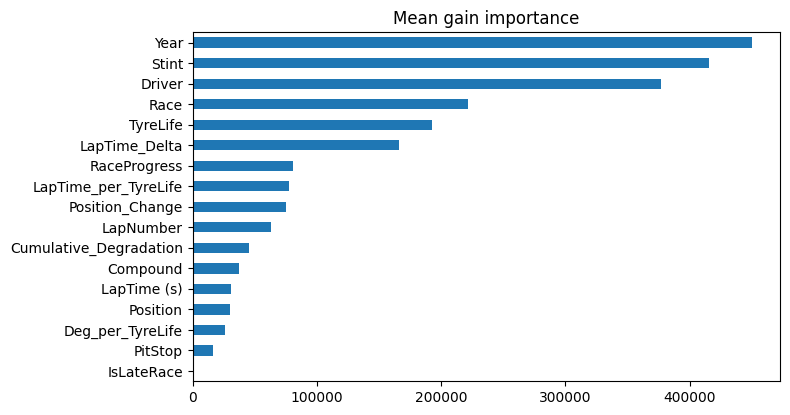

In [8]:
imp = feat_importance.mean(axis=1).sort_values(ascending=True)
plt.figure(figsize=(8, max(4, len(imp) * 0.25))); imp.plot.barh(); plt.title('Mean gain importance'); plt.tight_layout(); plt.show()

## 6. Submission

In [9]:
submission = sample_submission.copy()
submission[TARGET] = test_pred
submission.to_csv('submission.csv', index=False)
submission.head()

,id,PitNextLap
0,439140,0.003976
1,439141,0.001576
2,439142,0.005238
3,439143,0.132464
4,439144,0.886152
